<a href="https://colab.research.google.com/github/RENSHUZHE/HKU-DQMC/blob/main/DQMC_Part_1_Prerequisite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prerequsite

---
This notebook contains breif description of Monte Carlo method, with a pedagogical example of 2D Ising model with Metropolis algorithm.

The following text and codes are prepared by Mr. [Shuzhe Ren](https://quantummc.xyz/renshuzhe/) and [ZYM](https://quantummc.xyz/members/ziyang-meng/).


## Monte Carlo

The Monte Carlo method is a computational technique that uses random sampling to estimate numerical results and solve complex mathematical problems.

### Monte Carlo by directly sampling

The directly sampling method can be beautifully illustrated by a hypothetical game played by children in [Monte Carlo, Monaco](https://en.wikipedia.org/wiki/Monte_Carlo), the home of the famous casino that gave the technique its name. In this game, children randomly toss small pebbles into a square and calculate the ratio of stones that land inside an inscribed circle to estimate its relative area. Actually there is a very interesting story behind the Casino and the opium war and Hong Kong, that we can discuss during the class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Total Samples: 100
Points Inside Circle: 81
Estimated Pi: 3.240000
Actual Pi:    3.141593
Error:        0.098407


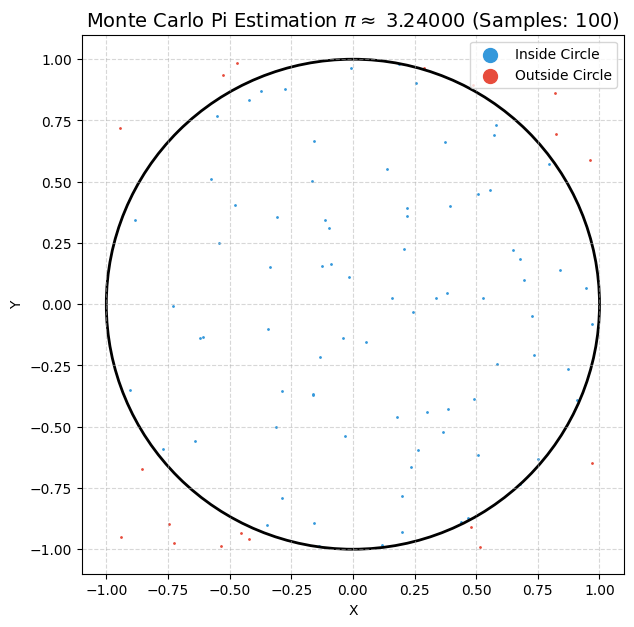

In [2]:
def estimate_pi(num_samples):
    # 1. Generate random (x, y) coordinates between -1 and 1
    # This represents throwing pebbles randomly into a 2x2 square
    points = np.random.uniform(-1, 1, size=(num_samples, 2))
    x, y = points[:, 0], points[:, 1]

    # 2. Check if the points fall inside the inscribed unit circle (x^2 + y^2 <= 1)
    distance_from_origin = x**2 + y**2
    inside_circle = distance_from_origin <= 1

    # 3. Calculate Pi estimate: 4 * (points inside / total points)
    num_inside = np.sum(inside_circle)
    pi_estimate = 4 * num_inside / num_samples

    print(f"Total Samples: {num_samples:,}")
    print(f"Points Inside Circle: {num_inside:,}")
    print(f"Estimated Pi: {pi_estimate:.6f}")
    print(f"Actual Pi:    {np.pi:.6f}")
    print(f"Error:        {abs(pi_estimate - np.pi):.6f}")

    # 4. Visualise the simulation
    plt.figure(figsize=(7, 7))

    # Plot points inside the circle in blue, outside in red
    plt.scatter(x[inside_circle], y[inside_circle], color='#3498db', s=1, label='Inside Circle')
    plt.scatter(x[~inside_circle], y[~inside_circle], color='#e74c3c', s=1, label='Outside Circle')

    # Draw the boundary circle line
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.title(fr"Monte Carlo Pi Estimation $\pi \approx$ {pi_estimate:.5f} (Samples: {num_samples:,})", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right', markerscale=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Run the simulation
estimate_pi(num_samples=100)

## Markov Chain Monte Carlo (MCMC)

Now imagine the same game, but played by adults. For them, the playground is huge (perhaps 20 metres by 20 metres), and it is impossible to throw a pebble far enough to cover the entire square. Therefore, they change their strategy.

Now, wherever they throw the pebble, they walk to that landing place, point in a random direction, and throw again. In this process, each throw is followed by the next and is no longer completely independent of the last throw. If they ever throw a pebble outside the square, they must fetch it, place it exactly on the spot of their previous throw, and continue from there.

Lastly, notice that the probability distribution of the next throw depends entirely on the adult's current position. It is completely independent of their past throws or how they arrived at that spot. This **'memoryless'** dependence on the present state is precisely what defines this process as a **Markov chain**.

Total Steps:   1,000,000
Step Size (δ): 0.1
Estimated Pi:  3.117056
Actual Pi:     3.141593
Error:         0.024537


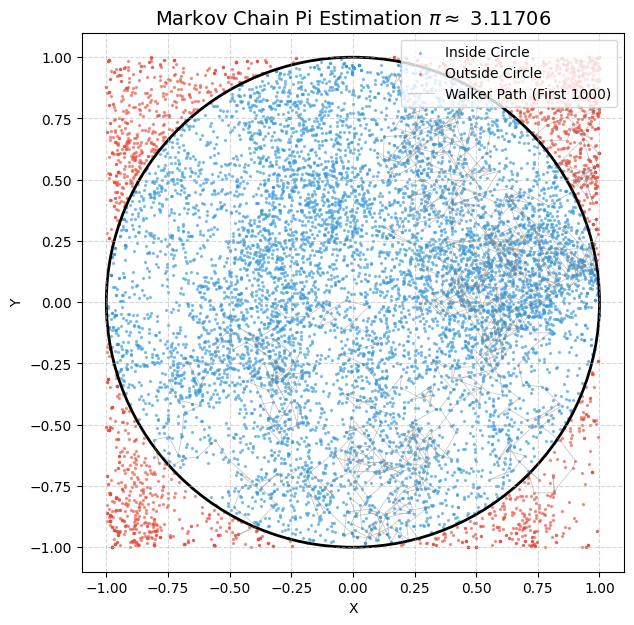

In [3]:
def markov_pi(num_samples, delta):
    # 1. Initialise variables exactly as in the pseudocode
    n_hits = 0
    x, y = 1.0, 1.0  # Starting exactly at the top-right corner

    # Arrays to store the path for visualisation
    x_history = np.zeros(num_samples)
    y_history = np.zeros(num_samples)

    # 2. The Markov Chain loop
    for i in range(num_samples):
        # Propose a random step within the throwing range (-delta to delta)
        delta_x = np.random.uniform(-delta, delta)
        delta_y = np.random.uniform(-delta, delta)

        # The referee checks if the new position is still inside the 2x2 square
        if abs(x + delta_x) < 1.0 and abs(y + delta_y) < 1.0:
            x = x + delta_x
            y = y + delta_y
        # If the move is rejected, x and y remain the same, and the adult stays put

        # Record the current position for our plot
        x_history[i] = x
        y_history[i] = y

        # 3. Check if the current position is inside the inscribed circle
        if x**2 + y**2 < 1.0:
            n_hits += 1

    # Calculate Pi
    pi_estimate = 4 * n_hits / num_samples

    print(f"Total Steps:   {num_samples:,}")
    print(f"Step Size (δ): {delta}")
    print(f"Estimated Pi:  {pi_estimate:.6f}")
    print(f"Actual Pi:     {np.pi:.6f}")
    print(f"Error:         {abs(pi_estimate - np.pi):.6f}")

    # 4. Visualise the Markov Chain
    plt.figure(figsize=(7, 7))

    # Check which points in our history landed inside the circle
    distances = x_history**2 + y_history**2
    inside = distances < 1.0

    # Plot the points (using a smaller sample size to prevent the plot from becoming a solid block of colour)
    plot_limit = min(num_samples, 10000)

    plt.scatter(x_history[:plot_limit][inside[:plot_limit]], y_history[:plot_limit][inside[:plot_limit]],
                color='#3498db', s=2, alpha=0.5, label='Inside Circle')
    plt.scatter(x_history[:plot_limit][~inside[:plot_limit]], y_history[:plot_limit][~inside[:plot_limit]],
                color='#e74c3c', s=2, alpha=0.5, label='Outside Circle')

    # Draw a faint line connecting the first 1000 steps to show the "Random Walk" path
    plt.plot(x_history[:1000], y_history[:1000], color='gray', linewidth=0.5, alpha=0.5, label='Walker Path (First 1000)')

    # Draw the boundary circle
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.title(fr"Markov Chain Pi Estimation $\pi \approx$ {pi_estimate:.5f}", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Run the simulation (feel free to change the delta value to see how it affects the chain)
markov_pi(num_samples=1000000, delta=0.1)

$\delta=0.3$ is an adjustable parameter. Try adjust it and see what happens.  

This is the adult's throwing range.
If you make $\delta$ very small (like 0.01), the algorithm takes tiny steps and explores the space very slowly, meaning you need millions of samples to get a good estimate.

If you make $\delta$ very large (like 2.0), almost every throw hits the boundary and gets rejected, stalling the chain.

## MCMC: Balance Conditions & Filters
The adults' strategy seems to work well, but it introduces a fundamental problem. We know direct sampling works because it relies on perfectly uniform sampling (*a concept often take for granted; the algorithm for generating a uniform distribution is fascinating, refer to [Werner Krauth's book: Statistical Mechanics: Algorithms and Computations](https://global.oup.com/booksites/content/9780198515364/) for more context*).

However, **how can we guarantee that the adults' random walk strategy actually results in a uniform distribution of pebbles**? What if there is a strong wind, or the ground is uneven?

You can likely imagine a practical solution to these realistic conditions. An east wind makes it artificially easy for pebbles to travel west. To counter this, the player need to apply a rule to "filter" their throws, deliberately rejecting some of the easy eastern throws to maintain an even spread across the playground.

This brings us to our theme below. We will formalise these intuitive concepts using mathematical language. We will introduce the **Balance Condition** *(the mathematical requirement to ensure the final distribution remains uniform)* and **Filters** *(the acceptance rules applied to the throwing pattern to ensure the Balance Condition is satisfied)*.

### Global Balance Condition
Let us introduce some mathematical machinery to tackle this problem. We want to study how the probability distribution $\pi_t(x)$ evolves in time. In the pebble game discussed earlier, we can choose the initial distribution to be $\pi_{t=0}(x) = \delta(0,0)$, representing a starting point at $(0,0)$ *(can be any arbitrary starting location).*

Time evolution is described by the transition matrix $P(x \rightarrow x')$, which is defined as the conditional probability to move from $x$ to $x'$ in one step. This gives us the following discrete Master equation:

$$\pi_t(x) = \sum_{x'} \pi_{t-1}(x') P(x' \rightarrow x).$$
This equation calculates the new state by summing past probabilities multiplied by their transition likelihoods. Due to the conservation of probability, the condition $\sum_{x'} P(x \rightarrow x') = 1$ ensures that probability is never lost.

Now, in most Monte Carlo simulations, we have an intended target sampling distribution $\pi(x)$, such as the uniform distribution in the pebble game.

We hope that after a sufficiently long time $t$, the Markov chain's sampling distribution $\pi_t$ will approach our target distribution $\pi$. When this happens, the master equation becomes:

$$\pi(x) = \sum_{x'} \pi(x') P(x' \rightarrow x).$$

In other words, $\pi$ becomes the steady state of the evolution equation. This requirement is known as the **global balance condition**, and it is necessary for our Markov chain to successfully converge to $\pi$.

While the global balance condition is fundamental, it is quite difficult to work with in practice. Usually, we face the inverse problem: we already know our target distribution $\pi$, and we need to construct a transition matrix $P(x \rightarrow x')$ that will get us there. For this engineering task, the **detailed balance condition** is far more practical:

$$\pi(x) P(x \rightarrow x') = \pi(x') P(x' \rightarrow x).$$

It is easy to prove that detailed balance automatically satisfies global balance, making it a stronger condition. It strictly enforces that the probability flow along the forward path $x \rightarrow x'$ exactly matches the flow along the reversed path $x' \rightarrow x$. Because of this symmetry, Markov chain algorithms that obey detailed balance are known as *reversible*.




### The Metropolis Filter

Using the detailed balance condition, we can motivate the construction of a transition matrix for a given target distribution $\pi(x)$. Let us propose the following relationship:

$$\pi(x) P(x \rightarrow x') \propto \min[\pi(x), \pi(x')] \quad \text{for } x \neq x'.$$

The detailed balance condition is automatically satisfied by this construction. By dividing both sides by $\pi(x)$, we arrive at the following proportionality:

$$P^{\text{Met}}(x \rightarrow x') \propto \min\left[1, \frac{\pi(x')}{\pi(x)}\right].$$

This minimum function represents the core logic of the Metropolis algorithm. To replace the proportionality sign with a strict equality, we must factor in the blind proposal generation. This gives us the complete equation for the transition matrix:

$$P^{\text{Met}}(x \rightarrow x') = \mathcal{A}(x \rightarrow x') α(x \rightarrow x').$$

In this exact expression:
* $P^{\text{Met}}(x \rightarrow x')$ is the full transition matrix.
* $\mathcal{A}(x \rightarrow x')$ is the *a priori* probability (the proposal distribution).
* $α(x \rightarrow x')$ is the Metropolis filter (the acceptance probability).

However, in most physical simulations, the *a priori* probability is chosen to be symmetrical, meaning $\mathcal{A}(x \rightarrow x') = \mathcal{A}(x' \rightarrow x)$. Because of this symmetry, the mathematical formulation simplifies beautifully. The acceptance probability, or Metropolis filter, becomes exactly:

$$\alpha(x \rightarrow x') = \min\left[1, \frac{\pi(x')}{\pi(x)}\right].$$


After learning MCMC, let's test these ideas in a physical setting to better understand these concepts and their applications.

## 2D Ising Model for Illustration


The **2D Ising model** describes spins $\sigma_k \in \{+1, -1\}$ (or $+/-$, representing spin up/dowm) for $k = 1, \ldots, L^2$, on a two-dimensional square lattice $L\times L$.

The **Hamiltonian** (or energy) of the system is given by:

$$E = -J \sum_{\langle k,l\rangle} \sigma_k\sigma_l = -\frac12 J \sum_k \sum_{l\in \text{Nbr(k)}}\sigma_k \sigma_l.$$

where:
* $J$ is a positive parameter (taken to be equal to 1) that represents the strength of the interaction between spins. It favours the spins on neigbour sites to align, i.e., ferromagnentic order. <font color="red"> (Can you imagine how the spins would like to arrange themselves if $J=-1$?)</font>

* The sum $\sum_{\langle k,l\rangle}$ is over all pairs of neighboring spins $\langle k,l\rangle$, with each edge (pair of neighbors) counted only once. (Prove the 2nd equality yourself.)

Lastly, we impose the **PBC: Periodic Boundary Condition**. *Meaning the whole lattice can be viewed as living on a torus.*

This motivates the code below.


In [4]:
"""
Here generate a L x L 2D square matrix with PBC enforced
The structure of matrix is like
{index(int):{'spin': -1, 'neighbours': (1, 1, 2, 2)}, ... }

"""

def gen_lattice_2D_square_lattice(L):
  lattice_dict={}
  N = L*L
  for i in range(N):
    temp = {"spin":np.random.choice([1,-1])}
    # Move to certain y level
    # Add x back
    x,y = i%L, i//L
    left_index = (x-1)%L + y*L #PBC
    right_index = (x+1)%L + y*L
    up_index = x + ((y-1)%L)*L
    down_index = x + ((y+1)%L)*L
    temp["neighbours"] = (left_index,right_index,up_index,down_index)
    lattice_dict[i] = temp

  return lattice_dict

Next, we define the physical quantities: energy, magnetisation, specific heat, and susceptibility.

The energy definition in the code is self-explanatory when checked against the Hamiltonian provided above.

The intensive magnetisation (magnetisation per site) is fundamentally defined as $m = \frac{1}{V} \sum_i \mu_i$, where $\mu_i$ is the individual microscopic magnetic moment and $V$ is the total volume. Since the magnetic moment in our lattice model is proportional to the dimensionless spin $\sigma_i$, we can evaluate the simpler quantity $m = \frac{1}{N} \sum_i \sigma_i$ to assess the macroscopic behaviour of the system, where $N$ is the total number of sites. Let the extensive, total magnetisation of the entire system be denoted as $\mathcal{M} = \sum_i \sigma_i$. <font color="red"> If one counts such $\mathcal{M}$ over many configurations, one will find the average is actually zero, this is because, spontaneous symmetry breaking will not happen on finite size lattices (think about how to correctly capture the magnetic order then?</font>


The macroscopic specific heat capacity per site is expressed as $C = \frac{1}{N} \frac{\partial \langle E \rangle}{\partial T}$. An obvious numerical approach would be to run two separate simulations at slightly different temperatures to approximate this derivative. However, a much more computationally efficient method arises from statistical mechanics.

By applying the chain rule, we can rewrite the temperature derivative in terms of the thermodynamic beta $\beta = 1/T$ (setting the Boltzmann constant $k_B = 1$):
$\frac{\partial \langle E \rangle}{\partial T} = \frac{\partial \langle E \rangle}{\partial \beta} \frac{\partial \beta}{\partial T} = -\frac{1}{T^2} \frac{\partial \langle E \rangle}{\partial \beta}$.

Using the partition function $Z = \sum e^{-\beta E_i}$, we know that the expected energy is $\langle E \rangle = -\frac{1}{Z} \frac{\partial Z}{\partial \beta}$. By taking the derivative of this expression with respect to $\beta$ (a useful exercise to prove to yourself), we find that $\frac{\partial \langle E \rangle}{\partial \beta} = \langle E \rangle^2 - \langle E^2 \rangle$. Substituting this back:

$$C = \frac{\langle E^2 \rangle - \langle E \rangle^2}{N T^2}.$$

Physically, this mathematical progression proves the fluctuation-dissipation theorem for this system. It demonstrates that the macroscopic specific heat of the lattice is entirely determined by the microscopic thermal fluctuations (the variance) of its internal energy.

Similarly, the total magnetic susceptibility measures the response of the total magnetisation $\mathcal{M}$ to a small external magnetic field $h$, defined as $\chi_{total} = \frac{\partial \langle \mathcal{M} \rangle}{\partial h}$. In the presence of this field, the Hamiltonian is modified exactly as one might expect:

$$H(\{\sigma\}) = H_0(\{\sigma\}) - h \mathcal{M}(\{\sigma\})$$

where $H_0$ is the internal interaction energy without the field. By following the exact same statistical logic used for the energy, taking the derivative of the partition function with respect to $h$ yields the variance of the total magnetisation.

To find the intensive susceptibility per site $\chi$, we divide the total susceptibility by $N$:
$$\chi = \frac{\chi_{total}}{N} = \frac{\beta}{N} \left( \langle \mathcal{M}^2 \rangle - \langle \mathcal{M} \rangle^2 \right) = \frac{1}{NT} \left( \langle \mathcal{M}^2 \rangle - \langle \mathcal{M} \rangle^2 \right)$$

There is one last quirk of the expression which require some modification. In physical world, we are dealing with systems of infinite size which promotes spontaneous symmetry breaking. If our Ising model is below critical temperature, the magnetisation is predominantly in one direction (not 0) even if the field $h$ goes to 0. (Because in Physics, we take $l\to \infty$ before $h\to 0$, this can't be captured directly in our finite simulation. )

Hence, we modify the definition of $\chi$, to reflect this:
$$\frac{1}{NT} \left( \langle \mathcal{M}^2 \rangle - \langle \mathcal{|M|} \rangle^2 \right)$$

***

*Note on notation: Standard physics literature can be notoriously inconsistent and confusing with magenetic moment, often using $M$ for intensive macroscopic magnetisation and $m$ for the microscopic magnetic moment, or vice versa. To avoid confusing the extensive total quantity with the intensive per-site quantity, this text deliberately uses $\mathcal{M}$ to denote the extensive total magnetisation and $m$ to denote the intensive magnetisation per site.*


In [5]:
"""
Below are the definitions of different physical quantities, including
- (Normalized) energy
- (Normalized) magnetization
- (Normalized) specific heat
- (Normalized) susceptibility
"""

# Energy
def Energy(lattice_dict,L):
  Energy = 0
  for i in range(L*L):
    S = lattice_dict[i]['spin']

    Neighbour_sum = 0
    for j in lattice_dict[i]['neighbours']:
      Neighbour_sum+=lattice_dict[j]['spin']

    Energy += -S*Neighbour_sum
  # I divide Neighbour_sum by 2 to deal with overcounting
  return float(Energy)/2

# Absolute value of magnetization (lower case m)
def M(lattice_dict,L):
  M = 0
  for i in lattice_dict.values():
    M+=i["spin"]
  M = abs(M/(L*L))
  return M

# specific_heat
def specific_heat(L,T,Energy_list):
  N = L**2
  Energy_mean = np.mean(Energy_list)
  Energy_square_mean =np.mean(np.square(Energy_list))
  return 1/(N*T**2)*(Energy_square_mean - Energy_mean**2)

# susceptibility
def susceptibility(L,T,M_list):
  N = L*L
  M_list = [i*N for i in M_list]
  M_mean = np.mean(np.abs(M_list))
  M_square_mean = np.mean(np.square(M_list))
  return (M_square_mean - M_mean**2)/(N*T)

###  Metropolis algorithm of 2D Ising Model

Here is our Marcov Chain step. Given a lattice pattern, what lattice pattern should we jump to next?

Recall metropollis algorithm above. We need both a priori probability and metropolis filter.

In this case, the a priori probability (proposal distribution) is a uniform distribution for all lattice pattern differed by 1 flip from current distribution. You can verify this satisfy the symmetry condition $\mathcal{A}(x \rightarrow x') = \mathcal{A}(x' \rightarrow x)$.

Hence, our metropolis filter is simplified to
$$\alpha(x \rightarrow x') = \min\left[1, \frac{\pi(x')}{\pi(x)}\right].$$

In physics, the equilibirium distribution is Boltzmann Distribution. Our filter is thus
$$\min\left[1, e^{-ΔE/T}\right].$$

<p align="center">
  <img src="https://github.com/RENSHUZHE/HKU-DQMC/blob/main/DQMC_prerequisite_metropolis%20filter_plot.png?raw=true" width="50%">
</p>



### Energy change due to flip
In a 2D Ising model on a square lattice, calculating the energy change $\Delta E$ requires looking only at a spin's nearest neighbours because the Hamiltonian strictly models local, short-range bond interactions. When a single spin flips, the energy contributions of all distant, non-neighbouring pairs remain identical before and after the flip.

Furthermore, because each lattice site has exactly four nearest neighbours, each restricted to a binary choice of spin ($+1$ or $-1$), the algebraic sum of these four surrounding spins can only yield five distinct outcomes: $+4, +2, 0, -2,$ or $-4$. When substituting these discrete sums into the local energy difference formula $\Delta E = 2J\sigma_i \sum \sigma_l$, the resulting energy change is strictly confined to five discrete values: $\pm 8J$, $\pm 4J$, or $0$.

In [6]:
"""
MC step

This function will perform 1 MC step for square lattice

Parameters
----------
1. lattice_dict
 {index(int):{'spin': -1, 'neighbours': (1, 1, 2, 2)}, ... }
2. T - temperature
3. L - the length of a square lattice
-------

Return
----------
1. lattice_dict - the flipped lattice_dict

-------

"""
def MC_step_square(lattice_dict,T,L):

  for j in range(L*L):
    index = np.random.randint(0,L*L)

    spin_at_index = lattice_dict[index]["spin"]

    Neighbour_sum = 0

    for i in lattice_dict[index]['neighbours']:
      Neighbour_sum+=lattice_dict[i]['spin']

    delta_E = 2*spin_at_index*Neighbour_sum

    if delta_E < 0 or (np.random.rand() < np.exp(-delta_E/T)): #Metropolis Filter
      lattice_dict[index]['spin'] *= -1

  return lattice_dict

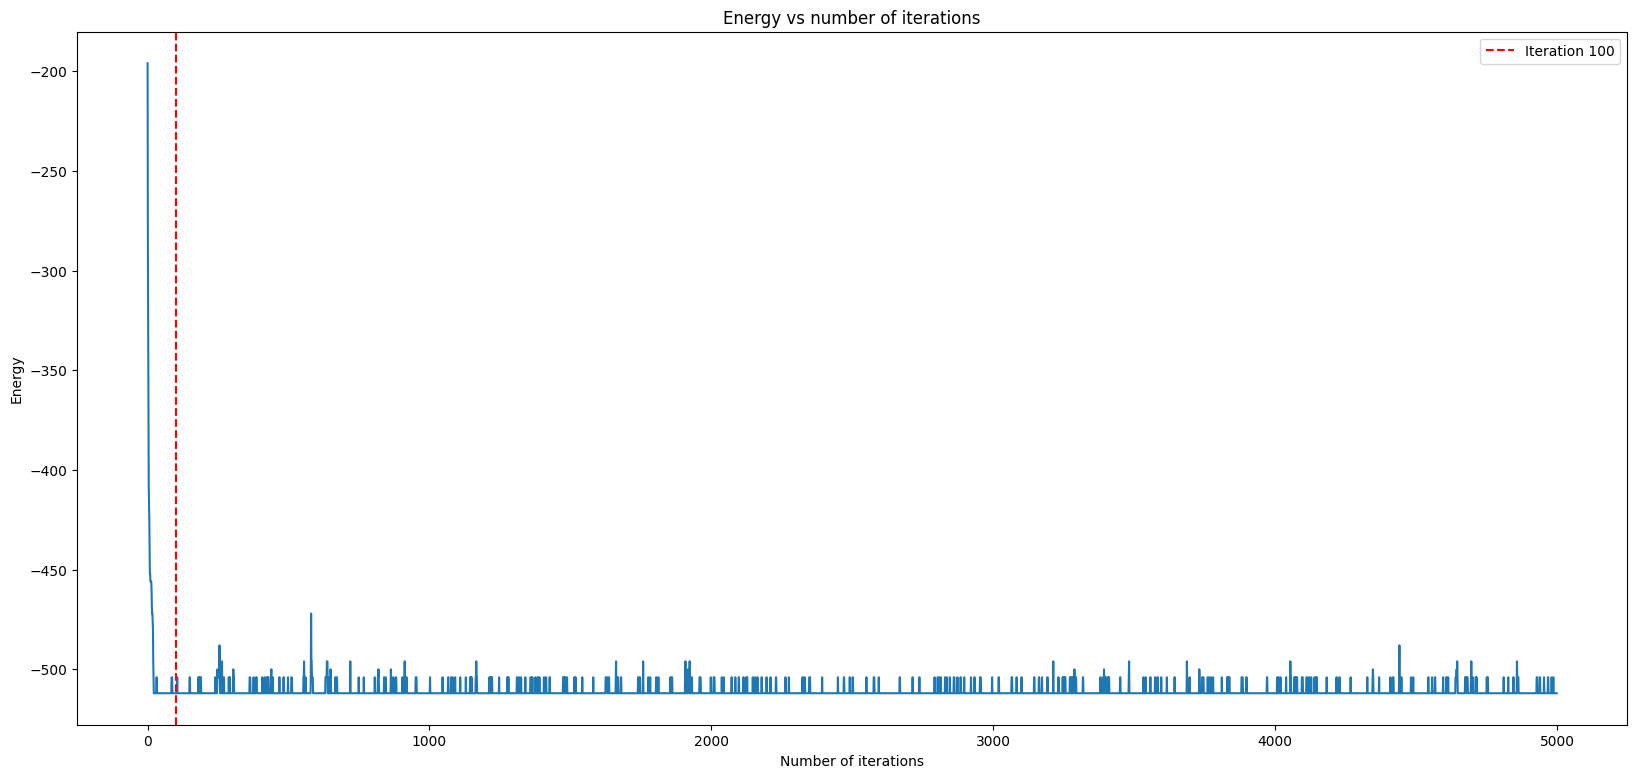

In [7]:
# Checking whether the energy values would converge over MC steps

def checking_converge(Temperature,iteration,L):
  E_list = []
  lattice_dict = gen_lattice_2D_square_lattice(L)

  for i in range(iteration):
    lattice_dict = MC_step_square(lattice_dict,Temperature,L)
    E_list.append(Energy(lattice_dict,L))

  return E_list

Temperature = 1     # Temperature
Iterations = 5000   # Totoal number of iterations
L = 16              # System size

plt.figure(figsize=(20,9))
Energy_list = checking_converge(Temperature,Iterations,L)

plt.plot([i for i in range(0,Iterations)],Energy_list)

plt.axvline(x=100, color='red', linestyle='--', label='Iteration 100')
plt.legend()

plt.xlabel("Number of iterations")
plt.ylabel("Energy")
plt.title("Energy vs number of iterations")
plt.show()

As you can see from the graph above, for the 2D square Ising lattice with $L=16$, $\beta = T = 1$, the energy converges after around 100 steps of iteration.

You can vary the system size $L$ and $\beta$, and see how these 2 quantities would affect the steps needed for thermalization.

In [8]:
"""
Metropolis_algorithm

temp_dict has the structure
{"Energy per N":[],"m^2":[],"|m|":[]}

expect_dict has the structure
{"Energy per N":[],"m^2":[],"|m|":[],"specific heat":[],"suspectility":[]}

Parameters
----------
1. lattice_dict
 {index(int):{'spin': -1, 'neighbours': (1, 1, 2, 2)}, ... }
2. T - temperature
3. L - the length of a square lattice
-------

Return
----------
1. expect_dict - it contains the mean value of (iterations num times) of  "Energy per N" ,"m^2" ,"|m|" ,"specific heat" ,"suspectility"
                  at a particular temperature
It has the structure
{"Energy per N":[],"m^2":[],"|m|":[],"specific heat":[],"suspectility":[]}

2.sd_dict - it contains the standard deviation of (iterations num times) of  "Energy per N" ,"m^2" ,"|m|" ,"specific heat" ,"suspectility"
                  at a particular temperature
It has the structure
{"Energy per N":[],"m^2":[],"|m|":[],"specific heat":[],"suspectility":[]}
-------

"""

def metropolis_algo_at_T(Temperature,iteration,L):

#1. Generate equilibrium lattice
  lattice_dict = gen_lattice_2D_square_lattice(L)
  for i in range(4000):                                        # thermialization steps. 4000 steps is enough to reach equilibrium (check last section)
    lattice_dict = MC_step_square(lattice_dict,Temperature,L)

 #2. Keep on running,collect data
  expect_dict = {"Energy per N":[],"Absolute M":[],"specific heat":[],"suspectility":[]}
  sd_dict = {"Energy per N":[],"Absolute M":[],"specific heat":[],"suspectility":[]}
  temp_dict={"Energy per N":[],"Absolute M":[],"Energy":[],"M^2":[]}

  for i in range(iteration):
    lattice_dict = MC_step_square(lattice_dict,Temperature,L)
    temp_dict["Energy"].append(Energy(lattice_dict,L))
    temp_dict["Energy per N"].append(Energy(lattice_dict,L)/(L**2))
    temp_dict["Absolute M"].append(M(lattice_dict,L))
    temp_dict["M^2"].append(M(lattice_dict,L)**2)


    if i%100==0 and i!=0:
      expect_dict["suspectility"].append(susceptibility(L,Temperature,temp_dict["Absolute M"]))
      expect_dict["specific heat"].append(specific_heat(L,Temperature,temp_dict["Energy"]))

      expect_dict["Energy per N"].append(np.mean(temp_dict["Energy per N"]))
      expect_dict["Absolute M"].append(np.mean(temp_dict["Absolute M"]))

      #clear the dictionary
      temp_dict.fromkeys(temp_dict,[])

  ## Take mean
  for i in expect_dict.keys():
    sd_dict[i] = np.std(expect_dict[i])
    expect_dict[i] = np.mean(expect_dict[i])

  print("Complete collecting data at temperature = {:.2f}".format(Temperature))

  return expect_dict,sd_dict

In [9]:
L = 10                      # system size
iteration = 1000
T = np.linspace(0.25,4,16)

final_mean_dict_mc = {"Energy per N":[],"Absolute M":[],"specific heat":[],"suspectility":[]}
final_sd_dict_mc = {"Energy per N":[],"Absolute M":[],"specific heat":[],"suspectility":[]}
for i in range(0,len(T)):

    expect_dict, sd_dict = metropolis_algo_at_T(T[i],iteration,L)

    for i in expect_dict.keys():
      final_mean_dict_mc[i].append(float(expect_dict[i]))
      final_sd_dict_mc[i].append(float(sd_dict[i]))


Complete collecting data at temperature = 0.25
Complete collecting data at temperature = 0.50
Complete collecting data at temperature = 0.75
Complete collecting data at temperature = 1.00
Complete collecting data at temperature = 1.25
Complete collecting data at temperature = 1.50
Complete collecting data at temperature = 1.75
Complete collecting data at temperature = 2.00
Complete collecting data at temperature = 2.25
Complete collecting data at temperature = 2.50
Complete collecting data at temperature = 2.75
Complete collecting data at temperature = 3.00
Complete collecting data at temperature = 3.25
Complete collecting data at temperature = 3.50
Complete collecting data at temperature = 3.75
Complete collecting data at temperature = 4.00


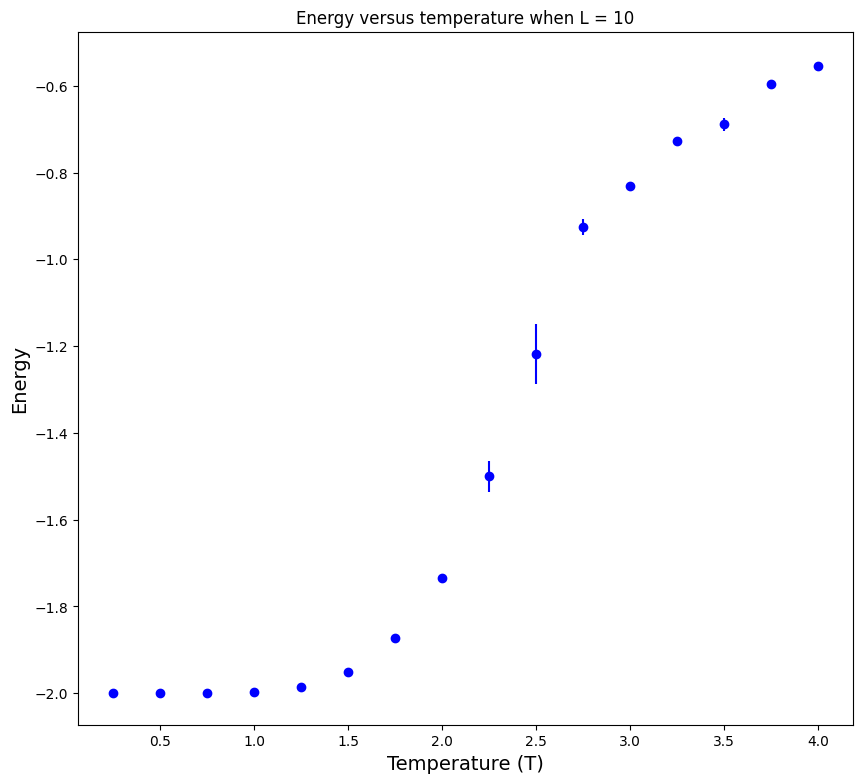

In [10]:
# <E>/N
plt.figure(figsize=(10,9))
plt.errorbar(T, final_mean_dict_mc["Energy per N"], final_sd_dict_mc["Energy per N"], fmt='o', color="blue")
plt.title("Energy versus temperature when L = {l}".format(l=L))
plt.xlabel("Temperature (T)", fontsize=14)
plt.ylabel("Energy", fontsize=14)
plt.show()

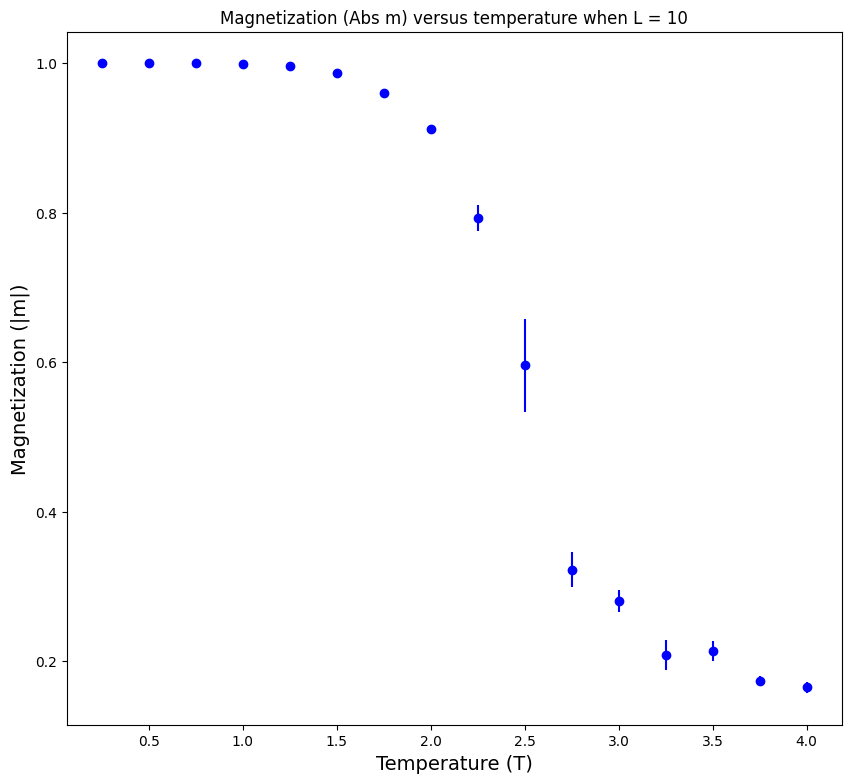

In [11]:
# Absolute m
plt.figure(figsize=(10,9))
plt.errorbar(T, final_mean_dict_mc["Absolute M"], final_sd_dict_mc["Absolute M"], fmt='o', color="blue")
plt.title("Magnetization (Abs m) versus temperature when L = {l}".format(l=L))
plt.xlabel("Temperature (T)", fontsize=14)
plt.ylabel("Magnetization (|m|)", fontsize=14)
plt.show()

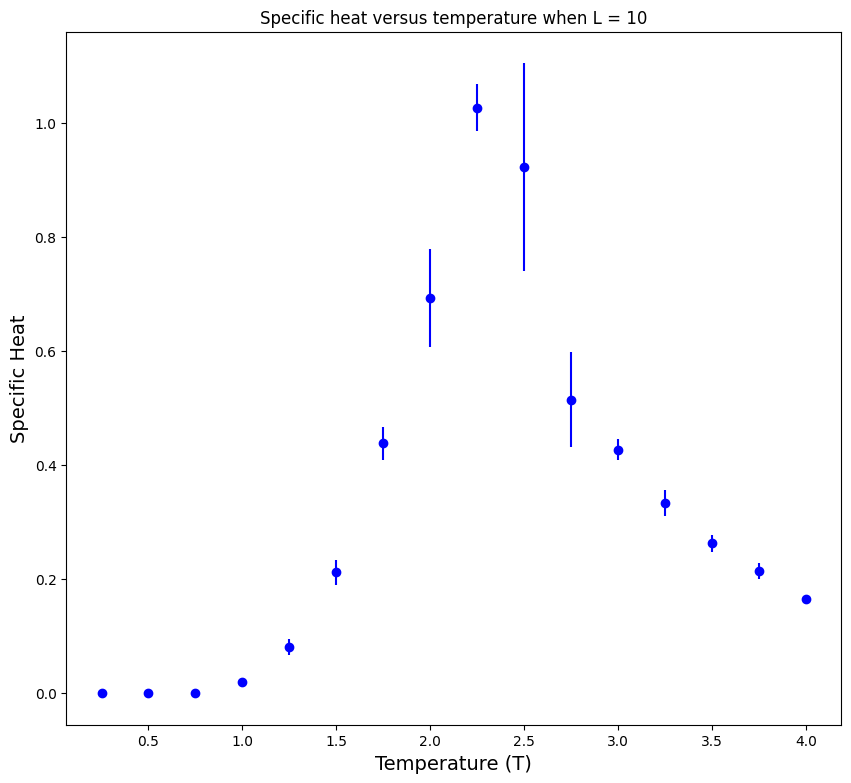

In [12]:
# Specific heat
plt.figure(figsize=(10,9))
plt.errorbar(T, final_mean_dict_mc["specific heat"], final_sd_dict_mc["specific heat"], fmt='o', color="blue")
plt.title("Specific heat versus temperature when L = {l}".format(l=L))
plt.xlabel("Temperature (T)", fontsize=14)
plt.ylabel("Specific Heat", fontsize=14)
plt.show()

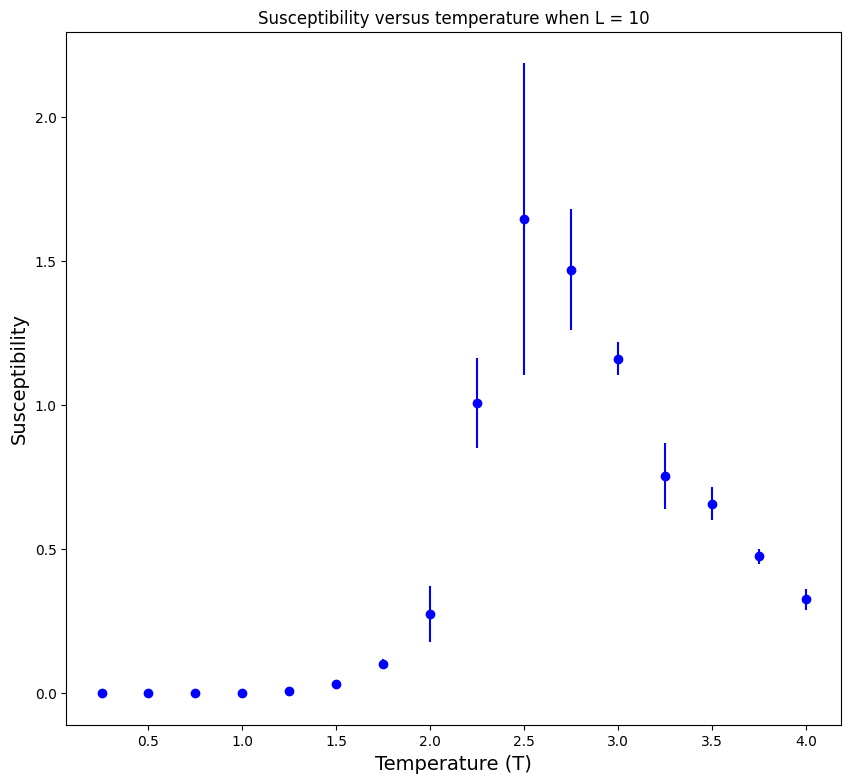

In [13]:
# Susceptibility
plt.figure(figsize=(10,9))
plt.errorbar(T, final_mean_dict_mc["suspectility"], final_sd_dict_mc["suspectility"], fmt='o', color="blue")
plt.title("Susceptibility versus temperature when L = {l}".format(l=L))
plt.xlabel("Temperature (T)", fontsize=14)
plt.ylabel("Susceptibility", fontsize=14)
plt.show()